# xrb-xlf-forwardmodel: end-to-end walkthrough

A short narrative through the whole pipeline: draw a synthetic XRB population, observe it through a realistic selection funnel, fit one galaxy two ways (selection-aware vs naive), then look at the repo's main figures: the recovery money plot, the posterior coverage curve, and the hierarchical stack, all assembled from the full runs.

Everything is reproducible from `configs/*.yaml` + the global seed. This notebook does light live compute (one draw, one fast fit) and loads the expensive figures from disk.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import yaml

# make src/ importable when running from notebooks/
_REPO = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, os.path.join(_REPO, 'src'))

from xlf_model.xlf import HMXBXLF, hmxb_from_config
from xlf_model.forward import detector_from_config, run_forward, format_funnel
from xlf_model.inference import make_hmxb_problem, fit_xlf

with open(os.path.join(_REPO, 'configs', 'xlf_defaults.yaml')) as fh:
    cfg = yaml.safe_load(fh)
print('loaded config; global seed =', cfg['seed'])

loaded config; global seed = 20260602


## 1. Draw a population

Draw the HMXB population of a star-forming galaxy from the Mineo+12 XLF (ξ = 1.49, γ = 1.60). The number of sources is Poisson around the XLF integral above `L_min`; luminosities come from the analytic inverse CDF.

In [2]:
SFR = 30.0          # Msun/yr -- a vigorously star-forming galaxy
distance_Mpc = 5.0  # nearby
rng = np.random.default_rng(cfg['seed'])

xlf = hmxb_from_config(cfg, SFR=SFR)
print(f'HMXB XLF: xi={xlf.xi}, gamma={xlf.gamma}, band {xlf.band}')
print(f'expected N(>L_min) = {xlf.expected_number():.1f} sources')

HMXB XLF: xi=1.49, gamma=1.6, band 0.5-8 keV
expected N(>L_min) = 4697.6 sources


## 2. Observe it: the selection funnel

Push the intrinsic population through the deep `chandra_like` detector: luminosity → flux (distance + absorption), a smooth completeness ramp (no hard cut), and Poisson count noise (which produces Eddington bias). The funnel reports drawn → above-limit → detected.

In [3]:
detector = detector_from_config(cfg, name='chandra_like')
res = run_forward(xlf, distance_Mpc, detector, rng,
                  absorption_flux_factor=1.0, component='HMXB')
print(format_funnel(res.funnel, title='HMXB funnel (this galaxy)'))

L_obs = res.table['L_obs']
L_obs = L_obs[L_obs > 0]
print(f'\nN detected = {L_obs.size}')

+----------------------------------------------------------+
| HMXB funnel (this galaxy)                                |
+----------------------------------------------------------+
| expected N (Poisson mean)                        4697.62 |
| n_drawn  (>L_min)                                   4762 |
| n_above_limit (F>5.0e-15)                    212 ( 4.5%) |
| n_detected                                   220 ( 4.6%) |
+----------------------------------------------------------+

N detected = 220


## 3. Fit one galaxy two ways

Fit the detected luminosities with the selection-aware likelihood (the completeness ramp) and the naive one (a hard flux cut, no ramp, no Eddington awareness). Same data; the only difference is `P_det`. We use a small live-point count here so the notebook runs fast; the full runs use 400.

In [4]:
from xlf_model.forward import luminosity_to_flux

truth = {'log10_xi_eff': float(np.log10(xlf.xi * SFR)), 'gamma': float(xlf.gamma)}

# selection-aware sees all detected sources
like_aware = make_hmxb_problem(L_obs, cfg, distance_Mpc=distance_Mpc,
                               detector=detector, selection_aware=True)
# naive sees only sources above its own hard cut
flux = luminosity_to_flux(L_obs, distance_Mpc)
L_naive = L_obs[flux >= detector.flux_limit_50]
like_naive = make_hmxb_problem(L_naive, cfg, distance_Mpc=distance_Mpc,
                               detector=detector, selection_aware=False)

fast = {'inference': {'sampler': {'n_live': 120}}}
fr_aware = fit_xlf(like_aware, fast, sampler='ultranest', seed=1)
fr_naive = fit_xlf(like_naive, fast, sampler='ultranest', seed=2)

for name, fr in [('selection-aware', fr_aware), ('naive', fr_naive)]:
    s = fr.summary()['gamma']
    print(f'{name:>16}:  gamma = {s["median"]:.3f} '
          f'(-{s["minus"]:.3f}/+{s["plus"]:.3f})   truth = {truth["gamma"]}')

[ultranest] Sampling 120 live points from prior ...


[ultranest] Explored until L=-2e+04  


[ultranest] Likelihood function evaluations: 2550


[ultranest]   logZ = -1.857e+04 +- 0.2167


[ultranest] Effective samples strategy satisfied (ESS = 494.8, need >400)


[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.11 nat, need <0.50 nat)


[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.22, need <0.5)


[ultranest]   logZ error budget: single: 0.24 bs:0.22 tail:0.01 total:0.22 required:<0.50


[ultranest] done iterating.


 selection-aware:  gamma = 1.583 (-0.045/+0.044)   truth = 1.6
           naive:  gamma = 1.522 (-0.050/+0.049)   truth = 1.6


The naive fit flattens the slope: it discards the information that faint sources are present but under-counted. Overlay the two posteriors with the truth marked:

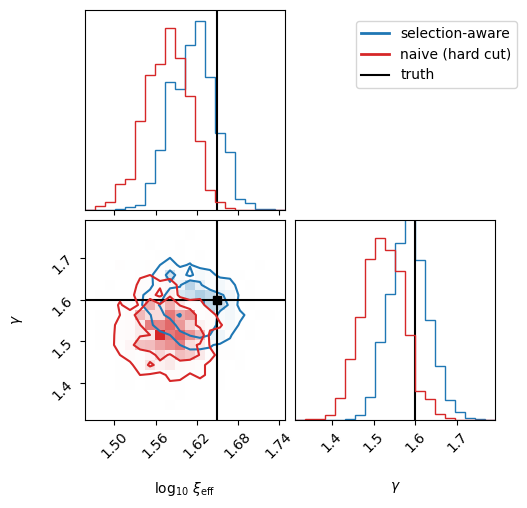

In [5]:
import corner
labels = [r'$\log_{10}\,\xi_{\rm eff}$', r'$\gamma$']
truths = [truth['log10_xi_eff'], truth['gamma']]
both = np.vstack([fr_aware.samples, fr_naive.samples])
rng_box = [(both[:, i].min(), both[:, i].max()) for i in range(both.shape[1])]
pad = [0.1 * (hi - lo) for lo, hi in rng_box]
rng_box = [(lo - p, hi + p) for (lo, hi), p in zip(rng_box, pad)]

fig = corner.corner(fr_aware.samples, labels=labels, truths=truths,
                    range=rng_box, color='C0', truth_color='k',
                    plot_datapoints=False, hist_kwargs={'density': True},
                    levels=(0.68, 0.95))
corner.corner(fr_naive.samples, fig=fig, range=rng_box, color='C3',
              plot_datapoints=False, hist_kwargs={'density': True},
              levels=(0.68, 0.95))
from matplotlib.lines import Line2D
fig.legend(handles=[Line2D([0],[0],color='C0',lw=2,label='selection-aware'),
                    Line2D([0],[0],color='C3',lw=2,label='naive (hard cut)'),
                    Line2D([0],[0],color='k',lw=1.5,label='truth')],
           loc='upper right', fontsize=10, bbox_to_anchor=(0.98, 0.92))
plt.show()

## 4. The money plot: bias & coverage vs N_det

The single fit above is one realization; the systematic behaviour shows up over a grid of detected counts and many realizations. This figure comes from the full recovery suite (1480 fits, `scripts/run_recovery_suite.py` → `analyze_recovery.py`). The naive fit is biased and its coverage collapses at high N; the selection-aware fit stays unbiased with near-nominal coverage.

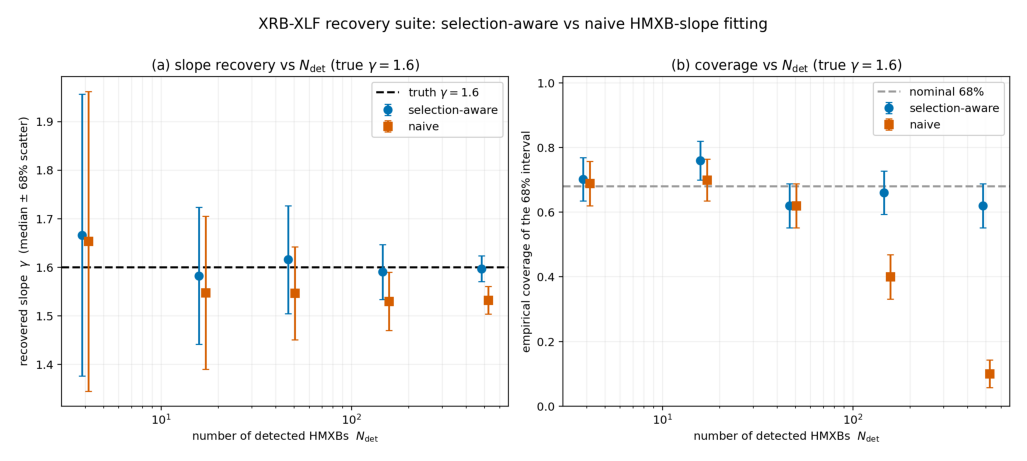

In [6]:
from matplotlib import image as mpimg
def show(path, figsize=(13, 6)):
    full = os.path.join(_REPO, path)
    if not os.path.exists(full):
        print('(figure not found -- run the relevant script:', path, ')')
        return
    img = mpimg.imread(full)
    plt.figure(figsize=figsize)
    plt.imshow(img); plt.axis('off'); plt.show()

show('outputs/recovery/money_plot.png')

## 5. Posterior coverage curve

Does the q% credible interval of the correct likelihood contain the truth q% of the time? Across 250 selection-aware fits at N_det ≈ 50 the curve is near-diagonal (max deviation 0.056), with a documented ~2% under-coverage from residual Eddington bias. Same coverage methodology as the sibling `sbi-xray-calibration` repo uses on neural posteriors.

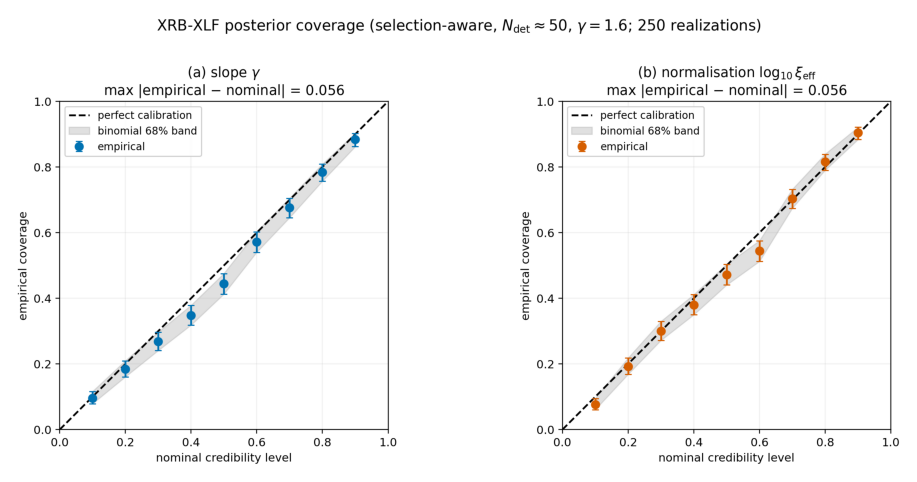

In [7]:
show('outputs/recovery/coverage_curve.png')

## 6. Hierarchical stack: pooling faint galaxies

Thirty galaxies sharing one global XLF, mostly in the few-detections regime, fit jointly. The joint fit is ≈ 2.4× tighter on γ than the single best galaxy, so the pooled few-detection galaxies constrain γ as well as the one richest galaxy.

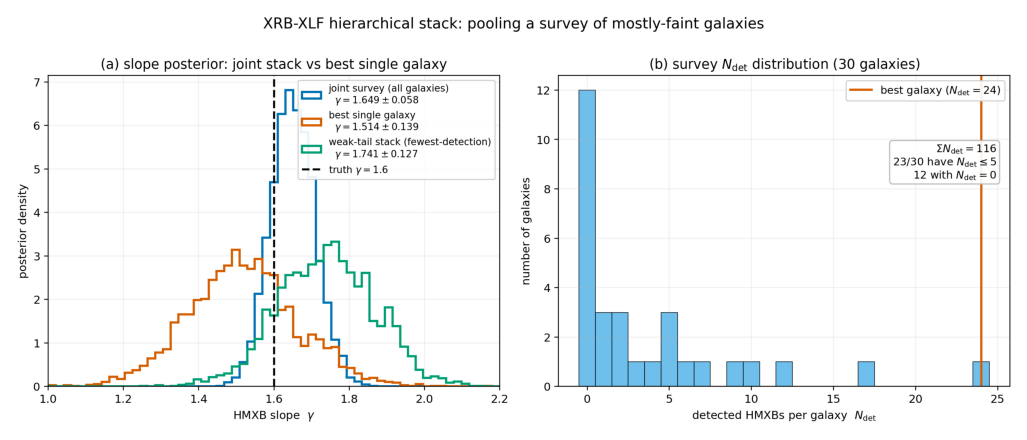

In [8]:
show('outputs/diagnostics/hierarchical_stack.png')

## Summary

Ignoring the selection function biases the recovered HMXB slope by Δγ ≈ −0.05 (and worse for steeper XLFs). Its credible interval also stops containing the truth: naive 68% coverage collapses to 0.10 at the bright end. The selection-aware unbinned Poisson-process likelihood is unbiased to |Δγ| ≤ 0.02 with coverage within a few percent of nominal across the whole 5–500 detected-source range. The only residual is a ~2% under-coverage from Eddington bias, documented in RESULTS.md.

See `RESULTS.md` for every number and `README.md` for the prior-work framing.